# Tornando visual
Esses códigos abaixo fornecem uma estimativa visual em tempo real de como estão acontecendo as mudanças de pesos e bias para que as ativações dos neurônios sejam feitas e tragam o resultado esperado.


Animação salva como 'neuron_weights_animation.gif'.


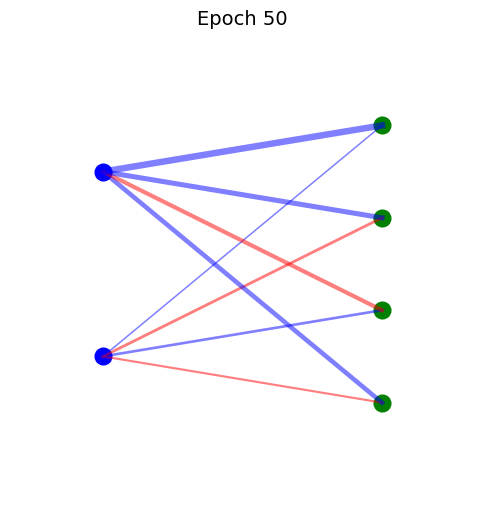

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Gerar dados sintéticos
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Criar modelo simples
model = Sequential([
    Input(shape=(2,)),
    Dense(4, activation='tanh', name='hidden'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer=SGD(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])

# 3. Callback para salvar pesos
class WeightHistory(Callback):
    def __init__(self):
        self.weights = []

    def on_epoch_end(self, epoch, logs=None):
        w = self.model.get_layer('hidden').get_weights()[0]
        self.weights.append(w.copy())

weight_history = WeightHistory()

# 4. Treinar modelo
model.fit(X_train, y_train, epochs=50, verbose=0, callbacks=[weight_history])

# 5. Criar animação com neurônios e conexões
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Posições dos neurônios
input_positions = [(2, 3), (2, 7)]  # 2 neurônios de entrada
hidden_positions = [(8, 2), (8, 4), (8, 6), (8, 8)]  # 4 neurônios ocultos

# Desenhar neurônios
for x, y in input_positions:
    ax.plot(x, y, 'o', color='blue', markersize=12)
for x, y in hidden_positions:
    ax.plot(x, y, 'o', color='green', markersize=12)

# Inicializar conexões
lines = []
for i_pos in input_positions:
    for h_pos in hidden_positions:
        line, = ax.plot([i_pos[0], h_pos[0]], [i_pos[1], h_pos[1]], color='gray', alpha=0.5)
        lines.append(line)

# Função de atualização da animação
def update(frame):
    weights = weight_history.weights[frame]
    ax.set_title(f"Epoch {frame+1}", fontsize=14)
    for i in range(2):  # entrada
        for j in range(4):  # oculto
            weight = weights[i][j]
            idx = i * 4 + j
            lines[idx].set_linewidth(abs(weight) * 5)
            lines[idx].set_color('red' if weight > 0 else 'blue')
    return lines

# Criar animação
ani = animation.FuncAnimation(fig, update, frames=len(weight_history.weights),
                              blit=True, repeat=False)

# Salvar como GIF
ani.save("neuron_weights_animation.gif", writer='pillow', fps=5)
print("Animação salva como 'neuron_weights_animation.gif'.")


# Dividindo uma imagem!
Aqui nós vamos dividir uma imagem e entender como ela é de forma digital, ou seja, como ela é representada em forma de matriz.

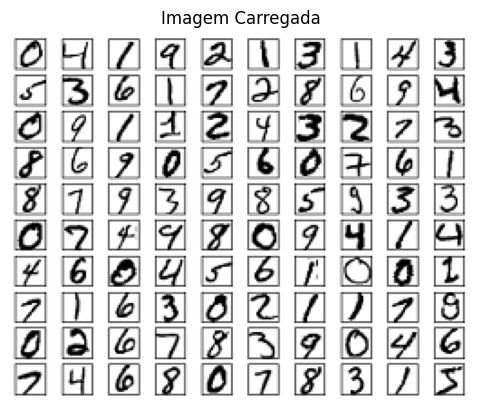

Matriz de pixels da imagem:
[[[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 ...

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]

 [[255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]
  ...
  [255 255 255 255]
  [255 255 255 255]
  [255 255 255 255]]]


In [107]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO

url = "https://www.deeplearningbook.com.br/wp-content/uploads/2017/12/mnist_100_digits.png"

# Fazer o download da imagem
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Converter a imagem para matriz NumPy
img_array = np.array(img)

# Exibir a imagem
plt.imshow(img_array)
plt.axis('off')
plt.title('Imagem Carregada')
plt.show()

# Exibir a matriz de pixels
print("Matriz de pixels da imagem:")
print(img_array)


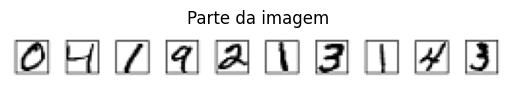

In [108]:
part_img = img_array[0:100][0:23]
plt.imshow(part_img)
plt.axis('off')
plt.title('Parte da imagem')
plt.show()

# Neurônios

In [109]:
import numpy as np

def neuron(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

inputs = np.array([1.0, 2.0])
weights = np.array([0.5, -1.5])
bias = 0.1

output = neuron(inputs, weights, bias)
print("Output:", output)

Output: -2.4


In [110]:
import numpy as np

class SimpleNeuron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()
        self.learning_rate = learning_rate

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        return x * (1 - x)

    def forward(self, inputs):
        self.inputs = inputs
        self.output = self.sigmoid(np.dot(inputs, self.weights) + self.bias)
        return self.output

    def backward(self, target):
        error = target - self.output
        delta = error * self.sigmoid_derivative(self.output)
        self.weights += self.learning_rate * delta * self.inputs
        self.bias += self.learning_rate * delta
        return error

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            total_error = 0
            for inputs, target in zip(X, y):
                self.forward(inputs)
                error = self.backward(target)
                total_error += error**2
            if epoch % 100 == 0:
                print(f"Epoch {epoch}, Error: {total_error:.4f}")


In [111]:
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])  # Saídas esperadas para OR lógico

In [112]:
SimpleNeuron(2).train(X, y)

Epoch 0, Error: 2.1914
Epoch 100, Error: 0.4973
Epoch 200, Error: 0.3368
Epoch 300, Error: 0.2467
Epoch 400, Error: 0.1912
Epoch 500, Error: 0.1543
Epoch 600, Error: 0.1282
Epoch 700, Error: 0.1090
Epoch 800, Error: 0.0943
Epoch 900, Error: 0.0828


# Images

In [113]:
from torchvision import datasets

mnist = datasets.MNIST(root='./data', train=True, download=True)

In [114]:
print("Tamanho dos dados de treino:", len(mnist.train_data))
print("Shape:", mnist.train_data[0].shape)
print("Tipo:", type(mnist.train_data[0]), "\n")

Tamanho dos dados de treino: 60000
Shape: torch.Size([28, 28])
Tipo: <class 'torch.Tensor'> 



/usr/local/lib/python3.12/dist-packages/torchvision/datasets/mnist.py:76: UserWarning: train_data has been renamed data
  warnings.warn("train_data has been renamed data")


In [115]:
mnist.data[0].shape

torch.Size([28, 28])

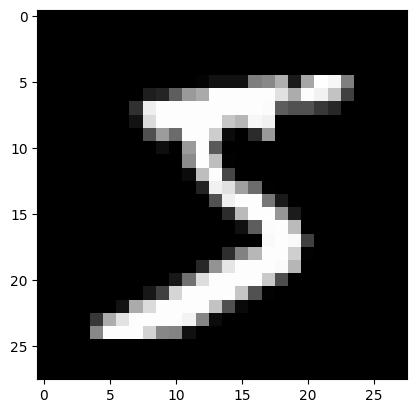

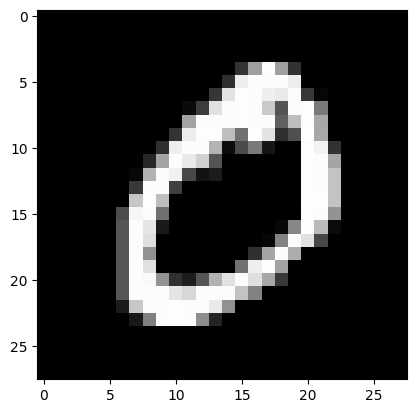

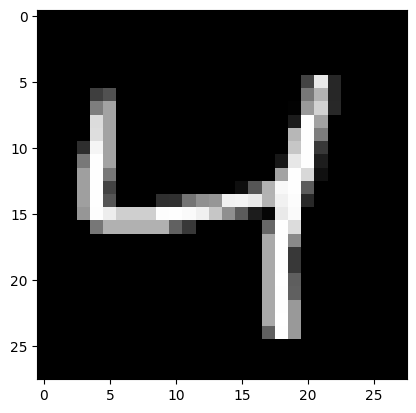

In [116]:
for i in range(3):
  plt.imshow(mnist.data[i], cmap='gray')
  plt.show()

# Reconhecendo digitos
URL livro: https://www.deeplearningbook.com.br/


marcação de capitulo: 18


In [117]:
import random
# vamos criar uma classe de rede
# sizes é um vetor que contém o tamanho das redes neurais em cada camada. ex: [2, 5, 6, 1]
class Network(object):
    def __init__(self,sizes):
      self.num_layers = len(sizes)
      self.sizes = sizes
      self.biases = [np.random.randn(y,1) for y in sizes[1:]]
      self.weights = [np.random.randn(y,x) for x,y in zip(sizes[:-1],sizes[1:])]

    def sigmoid(self,z):
      return 1.0/(1.0+np.exp(-z))

    def feedforward(self,a):
      for b,w in zip(self.biases,self.weights):
        a = self.sigmoid(np.dot(w,a)+b)
      return a

    def SGD(self,training_data,epochs,mini_batch_size,eta,test_data=None):
      training_data = list(training_data)
      n = len(training_data)

      if test_data:
        test_data = list(test_data)
        n_test = len(test_data)
      for j in range(epochs):
        random.shuffle(training_data)
        mini_batches = [training_data[k:k+mini_batch_size] for k in range(0,n,mini_batch_size)]
        for mini_batch in mini_batches:
          self.update_mini_batch(mini_batch,eta)

        if test_data:
          print("Epoch {} : {} / {}".format(j,self.evaluate(test_data),n_test))
        else:
          print("Epoch {} complete".format(j))

    def update_mini_batch(self, mini_batch, eta):
      nabla_b = [np.zeros(b.shape) for b in self.biases]
      nabla_w = [np.zeros(w.shape) for w in self.weights]
      for x, y in mini_batch:
        delta_nabla_b, delta_nabla_w = self.backprop(x, y)
        nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
        nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
      self.weights = [w-(eta/len(mini_batch))*nw
                      for w, nw in zip(self.weights, nabla_w)]
      self.biases = [b-(eta/len(mini_batch))*nb
                     for b, nb in zip(self.biases, nabla_b)]

    def backprop(self, x, y):
      nabla_b = [np.zeros(b.shape) for b in self.biases]
      nabla_w = [np.zeros(w.shape) for w in self.weights]

      activation = x

      activations = [x]
      zs = []
      for b, w in zip(self.biases, self.weights):
        z = np.dot(w, activation)+b
        zs.append(z)
        activation = self.sigmoid(z)
        activations.append(activation)

      delta = self.cost_derivative(activations[-1], y) * self.sigmoid_prime(zs[-1])
      nabla_b[-1] = delta
      nabla_w[-1] = np.dot(delta, activations[-2].transpose())

      for l in range(2, self.num_layers):
        z = zs[-l]
        sp = self.sigmoid_prime(z)
        delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
        nabla_b[-l] = delta
        nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())

      return (nabla_b, nabla_w)

In [118]:
# exemplo de uso
rede1 = Network([2,3,1])
print("W:",rede1.weights)
print("B:",rede1.biases)

W: [array([[ 1.58275481, -0.58036035],
       [ 0.89630941, -1.22705682],
       [ 1.62708375, -0.25247381]]), array([[ 0.79230358, -0.1947778 , -1.30636602]])]
B: [array([[ 0.87592427],
       [-0.47477288],
       [ 0.88549741]]), array([[1.50164715]])]


## exemplo com modelo MLP
Já pronto para uso


In [119]:
def rotate_vector(v, theta_deg):
    theta_rad = np.radians(theta_deg)
    rotation_matrix = np.array([
        [np.cos(theta_rad), -np.sin(theta_rad)],
        [np.sin(theta_rad),  np.cos(theta_rad)]
    ])
    h, w = v.shape
    center = np.array([w // 2, h // 2])
    rotated = np.zeros_like(v)
    for y in range(h):
        for x in range(w):
            pixel = v[y, x]
            coord = np.array([x, y]) - center
            new_coord = rotation_matrix @ coord + center
            new_x, new_y = new_coord.round().astype(int)
            if 0 <= new_x < w and 0 <= new_y < h:
                rotated[new_y, new_x] = pixel
    return rotated


In [120]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from torchvision.transforms import InterpolationMode
import torchvision.transforms.functional as TF


base_transform = transforms.Compose([
    transforms.ToTensor(),                         # -> float32 [C,H,W] em [0,1]
    transforms.Normalize((0.1307,), (0.3081,)),    # média e desvio padrão típicos do MNIST
])

dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
rand_rot_transform = transforms.Compose([
    transforms.RandomRotation(
        degrees=15,
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),
    base_transform,
])

rand_rot_transform2 = transforms.Compose([
    transforms.RandomRotation(
        degrees=25,
        interpolation=InterpolationMode.BILINEAR,
        fill=0
    ),
    base_transform,
])

train_orig = datasets.MNIST(root='./data', train=True, download=True, transform=base_transform)
train_randrot = datasets.MNIST(root='./data', train=True, download=True, transform=rand_rot_transform)
train_randrot2 = datasets.MNIST(root='./data', train=True, download=True, transform=rand_rot_transform2)
train_dataset = ConcatDataset([train_orig, train_randrot, train_randrot2])

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=base_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

KeyboardInterrupt: 

In [ ]:
len(train_dataset)

In [ ]:
# 2. Definição do modelo MLP
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)
        )


    def forward(self, x):
        return self.model(x)

# 3. Treinamento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0005)

epochs = 10
for epoch in range(epochs):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} concluída. ", loss.item())

# 4. Avaliação
model.eval()
correct = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()

print(f"Acurácia no teste: {100. * correct / len(test_loader.dataset):.2f}%")


In [ ]:
# apresenta erros no index 720
index = [2, 7, 999, 720]
for i in index:
  plt.imshow(dataset.data[i], cmap='gray')
  plt.show()

  with torch.no_grad():
      output = model(dataset.data[i].unsqueeze(0).float())
      pred = output.argmax(dim=1)
      print(f"Dígito previsto: {pred.item()}")


# faces

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
faces = fetch_olivetti_faces()

In [ ]:
plt.imshow(faces.images[2], cmap="gray")
plt.show()

# Análise do Mercado Financeiro de dividendos
Utilizando dados expostos no site fundamentus, assim vemos quais as melhores ações que pagam dividendos para comprar no momento do código ter rodado.
vamos trabalhar com ações e FIIs

In [121]:
!pip install fundamentus

In [128]:
import pandas as pd
import fundamentus

df = fundamentus.get_resultado_raw()
df = df.reset_index()

In [130]:
df.keys()

Index(['papel', 'Cotação', 'P/L', 'P/VP', 'PSR', 'Div.Yield', 'P/Ativo',
       'P/Cap.Giro', 'P/EBIT', 'P/Ativ Circ.Liq', 'EV/EBIT', 'EV/EBITDA',
       'Mrg Ebit', 'Mrg. Líq.', 'Liq. Corr.', 'ROIC', 'ROE', 'Liq.2meses',
       'Patrim. Líq', 'Dív.Brut/ Patrim.', 'Cresc. Rec.5a'],
      dtype='object', name='Multiples')

In [166]:
!pip install genai

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.9/831.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 4.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tiktoken (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tiktoken
Failed to build tiktoken
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tiktoken)


In [174]:
# ============================================================
# Análise Fundamentalista para Dividendos (Fundamentus -> Top 10)
# Versão com MAPEAMENTO ESTRITO das colunas solicitadas
# Autor: Hernande + M365 Copilot
# Requisitos: df (DataFrame do Fundamentus), Colab Secrets com GEMINI_API_KEY_2
# ============================================================

!pip -q install google-generativeai
import pandas as pd
import numpy as np
import os, time
from dataclasses import dataclass

# Colab secrets (se estiver no Colab)
try:
    from google.colab import userdata  # type: ignore
except Exception:
    userdata = None

from google import genai

# ============================================================
# 1) MAPEAMENTO ESTRITO das colunas do Fundamentus -> nomes internos
# ============================================================

STRICT_COLUMN_MAP = {
    'papel':                 'papel',
    'Cotação':               'cotacao',
    'P/L':                   'pl',
    'P/VP':                  'pvp',
    'PSR':                   'psr',
    'Div.Yield':             'dy',
    'P/Ativo':               'p_ativo',
    'P/Cap.Giro':            'p_cap_giro',
    'P/EBIT':                'p_ebit',
    'P/Ativ Circ.Liq':       'p_ativ_circ_liq',
    'EV/EBIT':               'ev_ebit',
    'EV/EBITDA':             'ev_ebitda',
    'Mrg Ebit':              'mrg_ebit',
    'Mrg. Líq.':             'mrg_liq',
    'Liq. Corr.':            'liq_corr',
    'ROIC':                  'roic',
    'ROE':                   'roe',
    'Liq.2meses':            'liq_2m',
    'Patrim. Líq':           'patrim_liq',
    'Dív.Brut/ Patrim.':     'divbrut_patrim',
    'Cresc. Rec.5a':         'cresc_rec_5a',
}

EXPECTED_SOURCE_COLS = list(STRICT_COLUMN_MAP.keys())  # para validar origem

def apply_strict_mapping(df_raw: pd.DataFrame) -> pd.DataFrame:
    src_missing = [c for c in EXPECTED_SOURCE_COLS if c not in df_raw.columns]
    if src_missing:
        raise ValueError(
            "As seguintes colunas NÃO foram encontradas no DataFrame de entrada (esperado exatamente como no Fundamentus):\n"
            f"{src_missing}\n\nColunas recebidas: {list(df_raw.columns)}"
        )
    df = df_raw.rename(columns=STRICT_COLUMN_MAP).copy()
    return df

# ============================================================
# 2) CONFIG: filtros e pesos (foco em dividendos)
# ============================================================

@dataclass
class Config:
    # Filtros mínimos
    MIN_DY: float = 0.05              # >= 5% de dividend yield
    MIN_ROE: float = 0.05             # >= 5%
    MIN_ROIC: float = 0.05            # >= 5%
    MIN_MRG_LIQ: float = 0.00         # >= 0% (evita prejuízo sistemático)
    MAX_DIVBRUT_PATRIM: float = 1.5   # Dívida bruta / Patrimônio <= 1.5
    MIN_LIQ_2M: float = 1_000_000.0   # Liquidez 2 meses mínima (R$)

    # Faixa aceitável para EV/EBIT
    EV_EBIT_MIN: float = 0.0
    EV_EBIT_MAX: float = 25.0

    # Outliers
    WINSOR_Q_LOW: float = 0.02
    WINSOR_Q_HIGH: float = 0.98
    IQR_K: float = 3.0

    # Pesos do score (somam 1.00)
    WEIGHTS: dict = None
cfg = Config()
cfg.WEIGHTS = {
    # Valuation (44%)
    'dy': 0.25,
    'pl': 0.05,
    'pvp': 0.04,
    'p_ebit': 0.05,
    'ev_ebit': 0.05,

    # Qualidade (32%)
    'roe': 0.10,
    'roic': 0.10,
    'mrg_liq': 0.06,
    'mrg_ebit': 0.06,

    # Estabilidade (14%)
    'divbrut_patrim': 0.10,  # menor é melhor
    'liq_corr': 0.04,        # ideal ~1.2-3.0
    # Crescimento & Liquidez (10%)
    'cresc_rec_5a': 0.06,
    'liq_2m': 0.04
}

# ============================================================
# 3) Funções auxiliares: parsing, outliers, scoring, Gemini
# ============================================================

def parse_numeric_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Converte colunas numéricas no padrão pt-BR (ex.: 1.234,56; 5,2%; etc)
    Percentuais alvo (frações): dy, mrg_ebit, mrg_liq, roe, roic, cresc_rec_5a
    """
    percent_cols = {'dy','mrg_ebit','mrg_liq','roe','roic','cresc_rec_5a'}
    for col in df.columns:
        if col == 'papel':
            continue
        s = df[col]
        if np.issubdtype(s.dtype, np.number):
            df[col] = pd.to_numeric(s, errors='coerce')
            continue

        s_str = s.astype(str).str.strip()
        had_percent = s_str.str.contains('%', na=False)

        s_str = (s_str
                 .str.replace('%','', regex=False)
                 .str.replace('.','', regex=False)  # milhares pt-BR
                 .str.replace(',','.', regex=False)) # decimais pt-BR

        s_num = pd.to_numeric(s_str, errors='coerce')
        if col in percent_cols:
            s_num = s_num / 100.0
        else:
            s_num = np.where(had_percent, s_num / 100.0, s_num)

        df[col] = pd.to_numeric(s_num, errors='coerce')

    df = df.replace([np.inf, -np.inf], np.nan)
    return df


def winsorize_series(s: pd.Series, q_low=0.02, q_high=0.98, iqr_k=3.0):
    s = pd.to_numeric(s, errors='coerce').replace([np.inf, -np.inf], np.nan)
    if s.dropna().empty:
        return s
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low_iqr = q1 - iqr_k * iqr
    high_iqr = q3 + iqr_k * iqr
    s = s.clip(lower=low_iqr, upper=high_iqr)
    lo = s.quantile(q_low)
    hi = s.quantile(q_high)
    return s.clip(lower=lo, upper=hi)


def pct_rank(s: pd.Series, higher_is_better=True, cfg: Config = cfg):
    s_w = winsorize_series(s, q_low=cfg.WINSOR_Q_LOW, q_high=cfg.WINSOR_Q_HIGH, iqr_k=cfg.IQR_K)
    ranks = s_w.rank(pct=True, ascending=not higher_is_better)
    return ranks.fillna(ranks.median())


def bounded_liq_corr_score(s: pd.Series, low_opt=1.2, high_opt=3.0, hard_min=0.7, hard_max=6.0):
    x = pd.to_numeric(s, errors='coerce').clip(lower=hard_min, upper=hard_max)
    score = pd.Series(index=x.index, dtype=float)
    mask_low = x <= low_opt
    score[mask_low] = (x[mask_low] - hard_min) / max(1e-9, (low_opt - hard_min))
    mask_mid = (x > low_opt) & (x <= high_opt)
    score[mask_mid] = 1.0
    mask_high = x > high_opt
    score[mask_high] = 1.0 - 0.5 * ((x[mask_high] - high_opt) / max(1e-9, (hard_max - high_opt)))
    return score.clip(lower=0.0, upper=1.0).fillna(0.5)


def apply_min_filters(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    g = df.copy()
    cond = pd.Series(True, index=g.index)
    cond &= (g['dy'] >= cfg.MIN_DY)
    cond &= (g['roe'] >= cfg.MIN_ROE)
    cond &= (g['roic'] >= cfg.MIN_ROIC)
    cond &= (g['mrg_liq'] >= cfg.MIN_MRG_LIQ)
    cond &= (g['divbrut_patrim'] <= cfg.MAX_DIVBRUT_PATRIM)
    cond &= (g['liq_2m'] >= cfg.MIN_LIQ_2M)
    cond &= g['ev_ebit'].between(cfg.EV_EBIT_MIN, cfg.EV_EBIT_MAX)
    return g[cond].copy()


def compute_scores(df: pd.DataFrame, cfg: Config) -> pd.DataFrame:
    out = df.copy()
    out['_score_dy']        = pct_rank(out['dy'], True)
    out['_score_pl']        = pct_rank(out['pl'], False)
    out['_score_pvp']       = pct_rank(out['pvp'], False)
    out['_score_p_ebit']    = pct_rank(out['p_ebit'], False)
    out['_score_ev_ebit']   = pct_rank(out['ev_ebit'], False)
    out['_score_roe']       = pct_rank(out['roe'], True)
    out['_score_roic']      = pct_rank(out['roic'], True)
    out['_score_mrg_liq']   = pct_rank(out['mrg_liq'], True)
    out['_score_mrg_ebit']  = pct_rank(out['mrg_ebit'], True)
    out['_score_divbrut_patrim'] = pct_rank(out['divbrut_patrim'], False)
    out['_score_liq_corr']  = bounded_liq_corr_score(out['liq_corr'])
    out['_score_cresc_rec_5a'] = pct_rank(out['cresc_rec_5a'], True)
    out['_score_liq_2m']       = pct_rank(out['liq_2m'], True)

    out['score_composto'] = (
        cfg.WEIGHTS['dy']               * out['_score_dy'] +
        cfg.WEIGHTS['pl']               * out['_score_pl'] +
        cfg.WEIGHTS['pvp']              * out['_score_pvp'] +
        cfg.WEIGHTS['p_ebit']           * out['_score_p_ebit'] +
        cfg.WEIGHTS['ev_ebit']          * out['_score_ev_ebit'] +
        cfg.WEIGHTS['roe']              * out['_score_roe'] +
        cfg.WEIGHTS['roic']             * out['_score_roic'] +
        cfg.WEIGHTS['mrg_liq']          * out['_score_mrg_liq'] +
        cfg.WEIGHTS['mrg_ebit']         * out['_score_mrg_ebit'] +
        cfg.WEIGHTS['divbrut_patrim']   * out['_score_divbrut_patrim'] +
        cfg.WEIGHTS['liq_corr']         * out['_score_liq_corr'] +
        cfg.WEIGHTS['cresc_rec_5a']     * out['_score_cresc_rec_5a'] +
        cfg.WEIGHTS['liq_2m']           * out['_score_liq_2m']
    )
    return out


def get_gemini_api_key():
    api_key = None
    if userdata is not None:
        try:
            api_key = userdata.get('GEMINI_API_KEY_2')
        except Exception:
            api_key = None
    if not api_key:
        api_key = os.environ.get('GEMINI_API_KEY_2', None)
    return api_key


import json
import random

def gemini_descriptions(top_df: pd.DataFrame,
                        model_candidate='gemini-2.5-flash',
                        max_retries=5,
                        base_delay=1.5,
                        temperature=0.4,
                        max_output_tokens=900) -> list:

    api_key = get_gemini_api_key()
    if not api_key:
        print("⚠️ Chave 'GEMINI_API_KEY_2' não encontrada. Pulando geração de descrições.")
        return ["(Sem Gemini: forneça a chave GEMINI_API_KEY_2 nos secrets do Colab.)"] * len(top_df)


    # Compacta números para reduzir tokens e facilitar parsing
    def fmt_num(x):
        if pd.isna(x):
            return None
        try:
            return float(f"{float(x):.4g}")  # 4 algarismos significativos
        except:
            return None

    # Prepara payload enxuto por papel
    itens = []
    for _, row in top_df.iterrows():
        itens.append({
            "papel": row.get("papel"),
            "cotacao": fmt_num(row.get("cotacao")),
            "dy": fmt_num(row.get("dy")),
            "pl": fmt_num(row.get("pl")),
            "pvp": fmt_num(row.get("pvp")),
            "p_ebit": fmt_num(row.get("p_ebit")),
            "ev_ebit": fmt_num(row.get("ev_ebit")),
            "ev_ebitda": fmt_num(row.get("ev_ebitda")),
            "mrg_liq": fmt_num(row.get("mrg_liq")),
            "mrg_ebit": fmt_num(row.get("mrg_ebit")),
            "roe": fmt_num(row.get("roe")),
            "roic": fmt_num(row.get("roic")),
            "cresc_rec_5a": fmt_num(row.get("cresc_rec_5a")),
            "divbrut_patrim": fmt_num(row.get("divbrut_patrim")),
            "liq_corr": fmt_num(row.get("liq_corr")),
            "liq_2m": fmt_num(row.get("liq_2m")),
        })

    sys_instructions = (
        "Você é um analista fundamentalista focado em renda por dividendos. "
        "Escreva um parágrafo (3–5 frases) por papel explicando por que é atrativo para dividendos agora, "
        "citando qualidade (ROE/ROIC, margens), valuation (DY, múltiplos), estabilidade (alavancagem, liquidez) "
        "e 1–2 riscos (ex.: compressão de margens, sensibilidade a juros). "
        "Não invente dados fora dos fornecidos."
    )

    # Pede SAÍDA ESTRITAMENTE JSON → [{papel, descricao}]
    user_prompt = {
        "instrucoes": sys_instructions,
        "formato_saida": "JSON estrito: lista de objetos {papel: string, descricao: string}.",
        "dados": itens
    }
    prompt_text = (
        "Gere descrições em português, objetivas, sem jargões. "
        "A saída deve ser ESTRITAMENTE um JSON válido (sem texto extra), "
        "com a mesma ordem dos itens de entrada e mapeando pelo campo 'papel'.\n\n"
        + json.dumps(user_prompt, ensure_ascii=False)
    )

    last_error = None

    clienteGemini = genai.Client(api_key=api_key)
    resp = clienteGemini.models.generate_content(model=model_candidate, contents=prompt_text)
    text = resp.text
    # Tenta extrair JSON (apoiando se o modelo envolver em texto)
    def extract_json_block(s: str) -> str:
                    start = s.find('[')
                    end = s.rfind(']')
                    if start != -1 and end != -1 and end > start:
                        return s[start:end+1]
                    return s  # pode já ser JSON puro

    json_text = extract_json_block(text)
    data = json.loads(json_text)

    # Monta lista na ordem do DataFrame
    by_papel = {d.get("papel"): d.get("descricao", "").strip() for d in data if isinstance(d, dict)}
    descs = []
    for _, row in top_df.iterrows():
      descs.append(by_papel.get(row["papel"], "(Sem descrição retornada pelo Gemini para este papel.)"))
    return descs

    print(f"⚠️ Falha ao gerar descrições com Gemini após tentativas. Último erro: {last_error}")
    return ["(Falha na geração com Gemini; tente novamente mais tarde.)"] * len(top_df)


# ============================================================
# 4) PIPELINE PRINCIPAL
# ============================================================

def analisar_dividendos(df_raw: pd.DataFrame, cfg: Config, top_n=10):
    # 4.1) Mapeamento estrito das colunas
    df = apply_strict_mapping(df_raw)

    # 4.2) Converter números (pt-BR -> num) e percentuais em fração
    df = parse_numeric_columns(df)

    # 4.3) Filtros mínimos (perfil dividendos)
    base = apply_min_filters(df, cfg)
    if base.empty:
        raise ValueError("Nenhum papel passou nos filtros mínimos. Ajuste parâmetros (ex.: reduzir MIN_DY ou EV/EBIT_MAX).")

    # 4.4) Scores
    scored = compute_scores(base, cfg)

    # 4.5) Top-N
    top = (scored
           .sort_values('score_composto', ascending=False)
           .head(top_n)
           .reset_index(drop=True))

    # 4.6) Descrições via Gemini
    top['descricao_gemini'] = gemini_descriptions(top)

    # 4.7) Colunas finais (mostra o essencial; PSR e outros ficam disponíveis no DataFrame)
    cols_show = [
        'papel','cotacao','dy','pl','pvp','p_ebit','ev_ebit','ev_ebitda',
        'mrg_liq','mrg_ebit','roe','roic','cresc_rec_5a','divbrut_patrim',
        'liq_corr','liq_2m','score_composto','descricao_gemini'
    ]
    cols_show = [c for c in cols_show if c in top.columns]
    return top[cols_show]

# ============================================================
# 5) EXECUÇÃO (supondo que você já tenha `df` carregado)
# ============================================================

try:
    df  # type: ignore
except NameError:
    raise RuntimeError("Carregue antes um DataFrame `df` com as colunas do Fundamentus (exatamente como especificado).")

top10 = analisar_dividendos(df, cfg, top_n=10)

pd.set_option('display.max_colwidth', None)
top10

Multiples,papel,cotacao,dy,pl,pvp,p_ebit,ev_ebit,ev_ebitda,mrg_liq,mrg_ebit,roe,roic,cresc_rec_5a,divbrut_patrim,liq_corr,liq_2m,score_composto,descricao_gemini
0,SMTO3,17.83,0.0509,11.55,0.85,5.42,12.32,3.72,0.0696,0.1482,0.0740,0.0593,0.1181,1.49,2.50,36656700.0,0.824286,"SMTO3 é atrativa para dividendos com um rendimento de 5,09%. A empresa demonstra qualidade razoável, com Retorno sobre Patrimônio Líquido (ROE) de 7,4% e margem líquida de 6,96%. Em termos de valuation, o papel apresenta múltiplos atrativos, como a relação preço/valor patrimonial de 0,85 e preço/lucro de 11,55. A estabilidade é um ponto forte, com liquidez corrente de 2,5, mas a alavancagem, medida pela relação dívida bruta/patrimônio líquido de 1,49, pode ser um risco. A modesta rentabilidade sobre o capital investido (ROIC de 5,93%) também é um fator a monitorar."
1,VIVT3,33.05,0.0520,18.28,1.57,12.42,13.68,5.02,0.1010,0.1490,0.0857,0.0798,0.0756,0.30,0.98,155361000.0,0.749135,"VIVT3 se mostra interessante para dividendos, oferecendo um rendimento de 5,2%. A qualidade da empresa é evidenciada por um Retorno sobre Patrimônio Líquido (ROE) de 8,57% e uma margem líquida sólida de 10,1%. Sua avaliação inclui uma relação preço/lucro de 18,28 e preço/valor patrimonial de 1,57. A estabilidade financeira é notável pela baixa alavancagem, com dívida bruta sobre patrimônio líquido de 0,3. Contudo, a liquidez corrente em 0,98 está ligeiramente abaixo de 1,0, e a avaliação de preço/lucro pode ser considerada elevada por alguns investidores."
2,CPLE3,11.86,0.0625,11.62,1.38,8.31,12.30,9.16,0.1269,0.1783,0.1189,0.0772,0.0206,0.78,1.13,57748500.0,0.724910,"CPLE3 destaca-se pelo seu dividend yield de 6,25%, atraente para investidores de renda. A qualidade da companhia é forte, com Retorno sobre Patrimônio Líquido (ROE) de 11,89% e margem líquida de 12,69%. O valuation é razoável, com relação preço/lucro de 11,62 e preço/valor patrimonial de 1,38. A estabilidade financeira é sólida, apresentando baixa alavancagem de 0,78 (dívida bruta/patrimônio líquido) e liquidez corrente de 1,13. Um risco a ser considerado é o crescimento de receita mais modesto nos últimos cinco anos, de 2,06%."
3,FLRY3,16.05,0.0617,14.49,1.63,7.45,10.24,6.00,0.0744,0.1503,0.1127,0.1140,0.2341,1.00,2.51,50719400.0,0.721633,"FLRY3 apresenta um atrativo dividend yield de 6,17%, com boa qualidade de negócios refletida em um ROE de 11,27% e um ROIC de 11,4%. A margem líquida da empresa é de 7,44%, enquanto o valuation mostra uma relação preço/lucro de 14,49 e preço/valor patrimonial de 1,63. Sua estabilidade financeira é robusta, com liquidez corrente de 2,51. A alavancagem, com dívida bruta sobre patrimônio líquido de 1,0, é um ponto de monitoramento, assim como a sensibilidade a custos que podem impactar a margem líquida."
4,AGRO3,20.30,0.0766,15.10,0.96,9.87,15.32,11.31,0.1178,0.1802,0.0634,0.0603,-0.0653,0.60,1.79,2793770.0,0.720816,"AGRO3 oferece um elevado dividend yield de 7,66%, tornando-a muito interessante para dividendos. A empresa exibe margens saudáveis, como margem líquida de 11,78% e margem EBIT de 18,02%. Seu valuation é atrativo, com relação preço/valor patrimonial de 0,96. A estabilidade financeira é boa, com alavancagem controlada (0,6 de dívida bruta/patrimônio líquido) e liquidez corrente de 1,79. No entanto, o crescimento de receita nos últimos cinco anos foi negativo em -6,53%, e a baixa liquidez do papel (R$ 2,79 milhões nos últimos 2 meses) representa um risco."
5,CPLE6,12.67,0.0644,12.42,1.48,8.88,12.87,9.58,0.1269,0.1783,0.1189,0.0772,0.0206,0.78,1.13,146654000.0,0.716645,"CPLE6 oferece um bom dividend yield de 6,44%, chamando a atenção para renda passiva. A qualidade da companhia é destacável, com um Retorno sobre Patrimônio Líquido (ROE) de 11,89% e uma sólida margem líquida de 12,69%. A avaliação é justa, com relação preço/lucro de 12,42 e preço/valor patrimonial de 1,48. A estabilidade financeira é positiva, com baixa alavancagem (0,78 de dívida bruta/patrimônio líquido) e l

In [142]:
top10["dy"] = [ round(i * 100, 2) for i in top10["dy"]]

In [143]:
top10

Multiples,papel,cotacao,dy,pl,pvp,p_ebit,ev_ebit,ev_ebitda,mrg_liq,mrg_ebit,roe,roic,cresc_rec_5a,divbrut_patrim,liq_corr,liq_2m,score_composto
0,SMTO3,17.83,5.09,11.55,0.85,5.42,12.32,3.72,0.0696,0.1482,0.0740,0.0593,0.1181,1.49,2.50,36656700.0,0.824286
1,VIVT3,33.05,5.20,18.28,1.57,12.42,13.68,5.02,0.1010,0.1490,0.0857,0.0798,0.0756,0.30,0.98,155361000.0,0.749135
2,CPLE3,11.86,6.25,11.62,1.38,8.31,12.30,9.16,0.1269,0.1783,0.1189,0.0772,0.0206,0.78,1.13,57748500.0,0.724910
3,FLRY3,16.05,6.17,14.49,1.63,7.45,10.24,6.00,0.0744,0.1503,0.1127,0.1140,0.2341,1.00,2.51,50719400.0,0.721633
4,AGRO3,20.30,7.66,15.10,0.96,9.87,15.32,11.31,0.1178,0.1802,0.0634,0.0603,-0.0653,0.60,1.79,2793770.0,0.720816
5,CPLE6,12.67,6.44,12.42,1.48,8.88,12.87,9.58,0.1269,0.1783,0.1189,0.0772,0.0206,0.78,1.13,146654000.0,0.716645
6,FESA4,6.53,7.65,8.46,0.68,13.12,9.29,3.60,0.1139,0.0734,0.0809,0.0553,0.0137,0.09,3.46,3660110.0,0.662648
7,PGMN3,3.58,6.46,13.71,0.80,3.28,5.42,3.07,0.0119,0.0497,0.0585,0.1012,0.1805,0.61,1.58,4960790.0,0.661633
8,ELET3,50.40,6.97,17.55,0.98,7.77,10.48,8.15,0.1518,0.3427,0.0559,0.0616,0.0887,0.59,1.86,353544000.0,0.645918
9,ELET6,53.15,7.27,18.50,1.03,8.20,10.90,8.48,0.1518,0.3427,0.0559,0.0616,0.0887,0.59,1.86,91313000.0,0.644184
